# MultiDiffusion Text2Panorama

MultiDiffusion is a unified framework that enables versatile and controllable image generation, using a pre-trained text-to-image diffusion model, without any further training or finetuning. MultiDiffusion Text2Panorama is integrated into **diffusers**, and can be run as follows:

## Setup

In [1]:
!pip install diffusers
!pip install transformers

## Model

This section implements the MultiDiffusion technique using the **StableDiffusionPanoramaPipeline** (standard generation struggles with high aspect ratios)

To generate panorama-like images make sure you pass the width parameter accordingly. We recommend a width value of 2048 which is the default.

With circular padding (circular_padding=True), the right and the left parts are matching (360° view)

In [3]:
import torch
from diffusers import StableDiffusionPanoramaPipeline, DDIMScheduler

# Choose the model

#model_ckpt = "stabilityai/stable-diffusion-2-base"
model_ckpt = "runwayml/stable-diffusion-v1-5"

scheduler = DDIMScheduler.from_pretrained(model_ckpt, subfolder="scheduler")
pipe = StableDiffusionPanoramaPipeline.from_pretrained(
     model_ckpt, scheduler=scheduler, torch_dtype=torch.float16
)

pipe = pipe.to("cuda")

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The StableDiffusionPanoramaPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


## Create a Panorama!

For more details, please visit our [project page](https://multidiffusion.github.io/) and our [paper](https://arxiv.org/abs/2302.08113).

  0%|          | 0/50 [00:00<?, ?it/s]

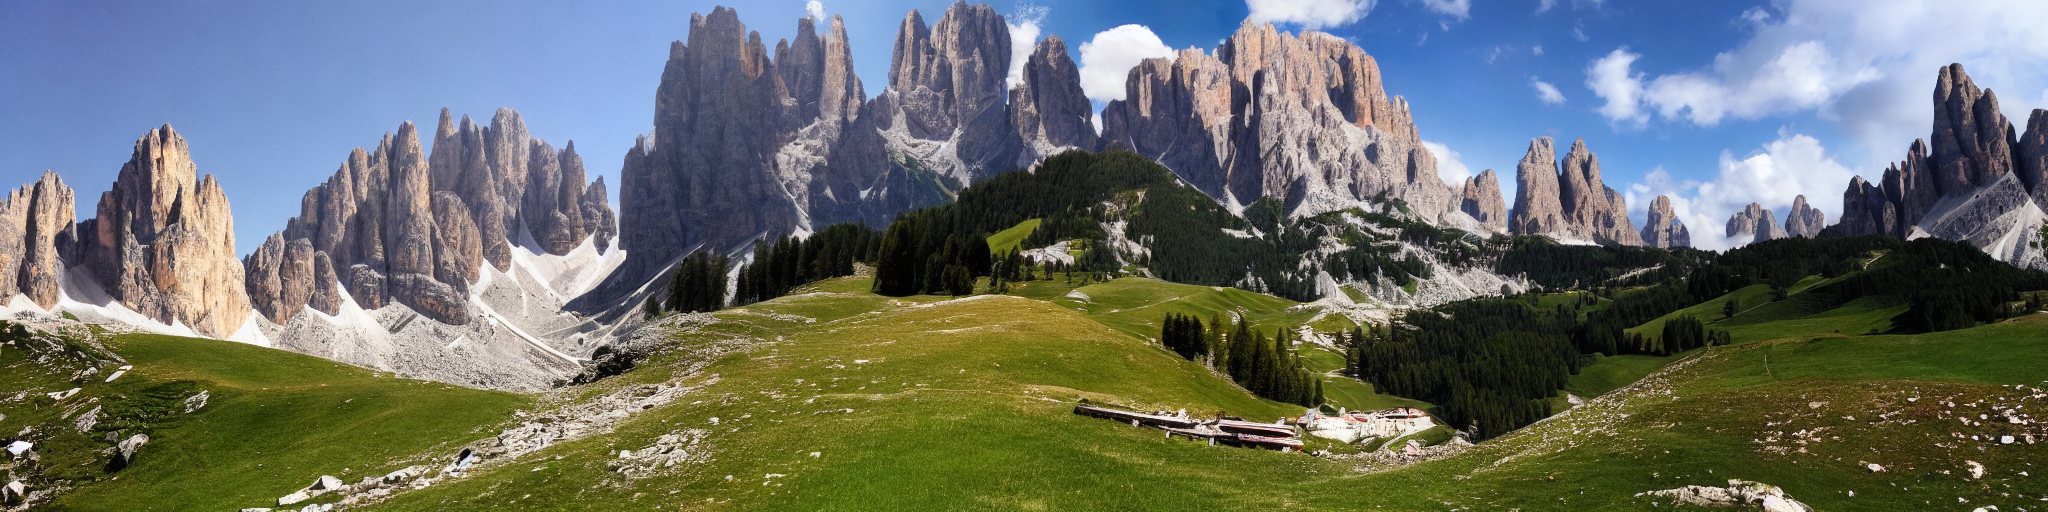

In [4]:
H = 512
W = 2048

prompt = "a photo of the dolomites"
image = pipe(prompt, height=H, width=W).images[0]
image

Save the result

In [ ]:
image.save("output.png")

## Bibliography

- **StableDiffusionPanoramaPipeline**: https://huggingface.co/docs/diffusers/v0.37.1/en/api/pipelines/panorama#diffusers.StableDiffusionPanoramaPipeline